In [22]:
# Build a reproducible scikit-learn regression pipeline to predict items_sold at a retail store.
# Dataset columns: transaction_date, store_id, store_size, location_type, 
# promotion_type, is_weekend, is_festival, competition_density, items_sold

# Task 1 - Date Feature Engineering
# From transaction_date, extract: year, month, day_of_week. 
# Create an additional binary feature is_month_end (set to 1 if day of month ≥ 25, else 0). 
# Display a sample of the resulting dataframe to confirm the new columns.

import pandas as pd
# Load the dataset
data = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert transaction_date to datetime
data['transaction_date'] = pd.to_datetime(data['transaction_date'])

# Extract year, month, day_of_week
data['year'] = data['transaction_date'].dt.year
data['month'] = data['transaction_date'].dt.month
data['day_of_week'] = data['transaction_date'].dt.dayofweek

# Create is_month_end feature
data['is_month_end'] = (data['transaction_date'].dt.day >= 25).astype(int)

# Display a sample of the resulting dataframe
print(data.head())


  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

In [23]:
# Task 2 - Temporal Train-Test Split 
# Sort the data by transaction_date. Use the most recent 20% of records as the test set and the remaining 80% as the training set. 
# Do not use a random split. In a markdown cell, explain why a random split is inappropriate for time-ordered data.
# Sort the data by transaction_date
data = data.sort_values(by='transaction_date')

# Determine the index for the 80% split
split_index = int(len(data) * 0.8)

# Create training and test sets
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]


# Task 2 - Random split not approproiate for time-ordered data. Why?

A random split is inappropriate for time-ordered data because it can lead to data leakage, 
where information from the future (test set) is inadvertently used to train the model. This can result
in overly optimistic performance metrics, as the model may learn patterns that are not truly predictive 
but are instead artifacts of the random split.

In [24]:
# Task 3 - Preprocessing Pipeline
# Build a scikit-learn Pipeline using ColumnTransformer that applies:

# One-hot encoding to promotion_type, location_type, and store_size
# Standard scaling to competition_density
# Ensure that the pipeline can be applied to both the training and test sets without data leakage.
# The pipeline must be fit only on the training set and applied to both train and test sets.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define the preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first'), ['promotion_type', 'location_type', 'store_size']),
        ('scaler', StandardScaler(), ['competition_density', 'year', 'month', 'day_of_week', 
                                      'is_month_end', 'is_weekend', 'is_festival'])
    ]
)

# Create the pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
])


Linear Regression - RMSE: 27.13, MAE: 21.07
Random Forest Regressor - RMSE: 31.98, MAE: 25.68


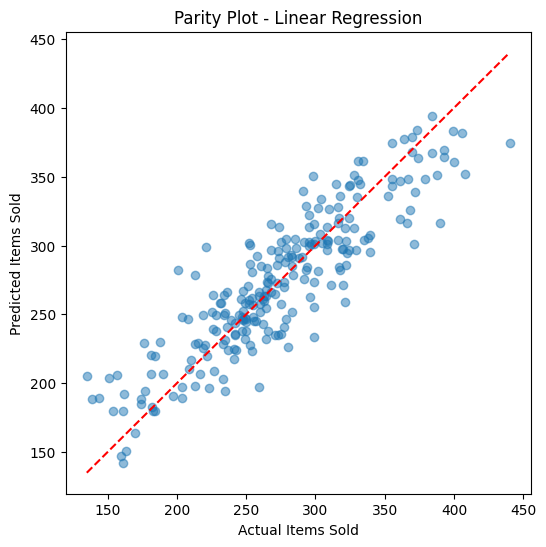

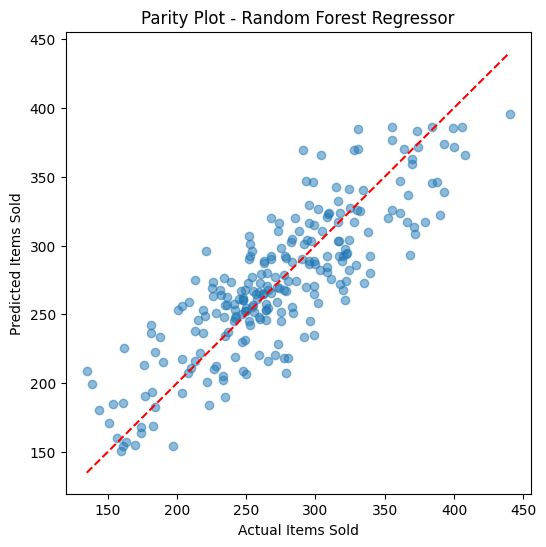

Top 5 Most Influential Features:
                    feature  importance
   onehot__store_size_small    0.184408
        scaler__is_festival    0.174561
onehot__location_type_urban    0.141088
        scaler__day_of_week    0.101210
scaler__competition_density    0.067342


In [25]:
# Task 4 - Model Training and Evaluation

# Train a Linear Regression model and a Random Forest Regressor (both inside the pipeline)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# For each model, report RMSE and MAE on the test set
# Define the models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42)
}

# Train and evaluate each model
for model_name, model in models.items():
    # Create a pipeline with the preprocessor and the model
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Fit the model on the training data
    model_pipeline.fit(train_data.drop(columns=['items_sold', 'transaction_date', 'store_id']), train_data['items_sold'])
    
    # Predict on the test set
    predictions = model_pipeline.predict(test_data.drop(columns=['items_sold', 'transaction_date', 'store_id']))
    
    # Calculate evaluation metrics
    from sklearn.metrics import mean_absolute_error
    import numpy as np
    rmse = np.sqrt(mean_squared_error(test_data['items_sold'], predictions))
    mae = mean_absolute_error(test_data['items_sold'], predictions)
    print(f"{model_name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    

# Produce a parity plot (predicted vs actual items_sold) for each model, with a diagonal reference line
import matplotlib.pyplot as plt
# Create parity plots for each model
for model_name, model in models.items():
    # Create a pipeline with the preprocessor and the model
    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Fit the model on the training data
    model_pipeline.fit(train_data.drop(columns=['items_sold', 'transaction_date', 'store_id']), train_data['items_sold'])
    
    # Predict on the test set
    predictions = model_pipeline.predict(test_data.drop(columns=['items_sold', 'transaction_date', 'store_id']))
    
    # Create parity plot
    plt.figure(figsize=(6, 6))
    plt.scatter(test_data['items_sold'], predictions, alpha=0.5)
    plt.plot([test_data['items_sold'].min(), test_data['items_sold'].max()], 
             [test_data['items_sold'].min(), test_data['items_sold'].max()], 
             'r--')  # Diagonal reference line
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.title(f'Parity Plot - {model_name}')
    plt.show()

# Print the feature importances from the Random Forest and identify the top 5 most influential features
# Fit the Random Forest model to get feature importances
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(train_data.drop(columns=['items_sold', 'transaction_date', 'store_id']), train_data['items_sold'])
feature_importances = rf_pipeline.named_steps['model'].feature_importances_

# Identify the top 5 most influential features
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})
importance_df = importance_df.sort_values('importance', ascending=False)
print("Top 5 Most Influential Features:")
print(importance_df.head(5).to_string(index=False))
    